In [4]:
import pandas as pd
import bioframe as bf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statannotations.Annotator import Annotator
from coolpuppy import coolpup

from ggner_3d.cm import get_dots_df, get_expected_cis_df, CLR_CONNS
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict

colors = ['#465775', '#A63446', '#F5B841', '#9DBBAE']
RESOLUTION = 10000

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
# read idr thresholded peaks

ctcf_wt_peaks = pd.read_csv('/home/carlos/oldies/ner_collab/ctcf/idr/WT_NoUV_idr_conservative_merged.narrowPeak', sep='\t', header=None)
ctcf_wt_peaks = ctcf_wt_peaks.loc[ctcf_wt_peaks[4] >= 540][[0,1,2]].rename(columns={0: 'chrom', 1: 'start', 2: 'end'})

ctcf_xpc_ko_peaks = pd.read_csv('/home/carlos/oldies/ner_collab/ctcf/idr/XPCKO_NoUV_idr_conservative_merged.narrowPeak', sep='\t', header=None)
ctcf_xpc_ko_peaks = ctcf_xpc_ko_peaks.loc[ctcf_xpc_ko_peaks[4] >= 540][[0,1,2]].rename(columns={0: 'chrom', 1: 'start', 2: 'end'})

In [6]:
xpc_peaks = pd.read_csv('/home/carlos/oldies/ner_collab/xpc_chipseq/narrow_peak/XPC_WT_noUV_merged.narrowPeak', sep='\t', header=None)[[0,1,2]].rename(columns={0: 'chrom', 1: 'start', 2: 'end'})

In [9]:
# compute preserved loops between WT and XPC-KO

wt_nouv_loops = get_dots_df("WTnoUV", 10000)
xpc_ko_nouv_loops = get_dots_df("XPCnoUV", 10000)

results = compare_loops_with_strength(
    wt_nouv_loops,
    xpc_ko_nouv_loops,
    clustering_radius=20000,
    compute_strength=False
)

preserved_df = results['common_loops']
preserved_df['chrom1'] = preserved_df['chrom1_sample_a'].astype(str)
preserved_df['chrom2'] = preserved_df['chrom2_sample_a'].astype(str)
preserved_df['start1'] = preserved_df['start1_sample_a'].astype(int)
preserved_df['start2'] = preserved_df['start2_sample_a'].astype(int)
preserved_df['end1'] = preserved_df['end1_sample_a'].astype(int)
preserved_df['end2'] = preserved_df['end2_sample_a'].astype(int)

In [10]:
all_anchors = pd.concat([
    preserved_df[['chrom1', 'start1', 'end1']].rename(columns={'chrom1': 'chrom', 'start1': 'start', 'end1': 'end'}),
    preserved_df[['chrom2', 'start2', 'end2']].rename(columns={'chrom2': 'chrom', 'start2': 'start', 'end2': 'end'})
]).drop_duplicates().reset_index(drop=True)
all_anchors[['idx']] = all_anchors.index.to_frame()

In [11]:
# calculate coverage

ctcf_wt_coverage = bf.coverage(all_anchors, ctcf_wt_peaks)
ctcf_xpc_ko_coverage = bf.coverage(all_anchors, ctcf_xpc_ko_peaks)
xpc_coverage = bf.coverage(all_anchors, xpc_peaks)

In [12]:
# pick only anchors with ctcf binding in both conditions

mask = (ctcf_wt_coverage['coverage'] > 0) | (ctcf_xpc_ko_coverage['coverage'] > 0)
ctcf_wt_coverage = ctcf_wt_coverage.loc[mask].reset_index(drop=True)
ctcf_xpc_ko_coverage = ctcf_xpc_ko_coverage.loc[mask].reset_index(drop=True)
xpc_coverage = xpc_coverage.loc[mask].reset_index(drop=True)

Processing pol2 - /home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw
Processing pol2 - /home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw
Processing pol2 - /home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw


/tmp/ipykernel_708474/1626772263.py:29: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=placeholder_df, x='cov_diff', y='pol2_cov', palette='viridis', alpha=0.7)


Text(0.5, 1.0, 'CTCF Coverage Difference vs Pol2 Coverage at Preserved Loop Anchors')

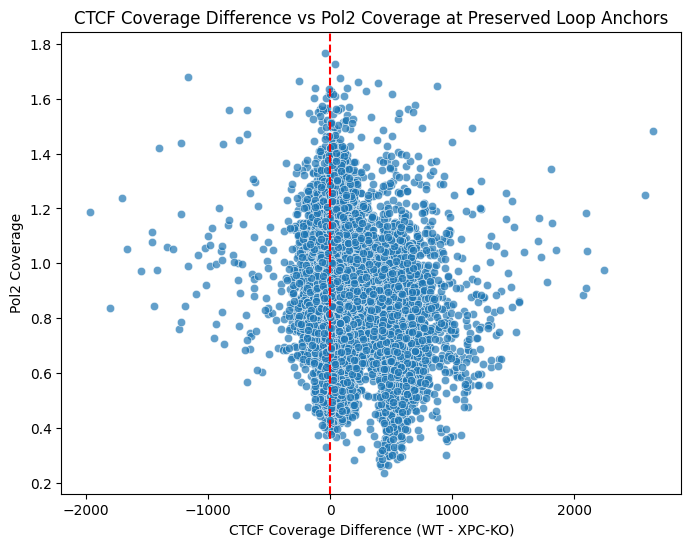

In [44]:
# pol2 levels

# pol2_bw = {'pol2': ['/home/carlos/Clone/ggner-3d/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw']}
pol2_bw = {'pol2': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw'
],}

pol2_coord_df = ctcf_wt_coverage[['chrom', 'start', 'end']].copy()
pol2_coord_df['flank_start'] = pol2_coord_df['start']
pol2_coord_df['flank_end'] = pol2_coord_df['end']

pol2_coverage = stackup_bw_dict(
    pol2_bw,
    pol2_coord_df,
    nbins=1
)['pol2']

# prepare coverage difference
coverage_diff = ctcf_wt_coverage['coverage'] - ctcf_xpc_ko_coverage['coverage']

placeholder_df = ctcf_wt_coverage[['chrom', 'start', 'end']].copy()
placeholder_df['cov_diff'] = coverage_diff
placeholder_df['pol2_cov'] = np.log1p(pol2_coverage)

# hexbin plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=placeholder_df, x='cov_diff', y='pol2_cov', palette='viridis', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('CTCF Coverage Difference (WT - XPC-KO)')
plt.ylabel('Pol2 Coverage')
plt.title('CTCF Coverage Difference vs Pol2 Coverage at Preserved Loop Anchors')

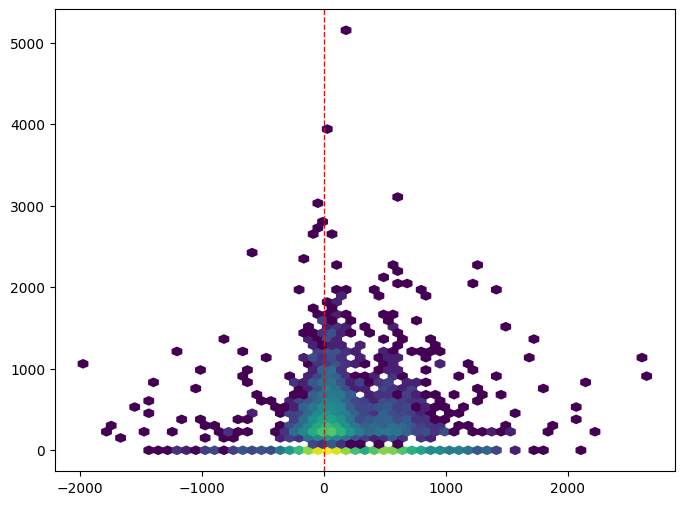

In [52]:
import matplotlib.pyplot as plt
import numpy as np

coverage_diff = ctcf_wt_coverage['coverage'] - ctcf_xpc_ko_coverage['coverage']
placeholder_df = ctcf_wt_coverage[['chrom', 'start', 'end']].copy()
placeholder_df['cov_diff'] = coverage_diff
placeholder_df['xpc_coverage'] = xpc_coverage['coverage']


x = placeholder_df["cov_diff"].to_numpy()
y = placeholder_df["xpc_coverage"].to_numpy()

plt.figure(figsize=(8, 6))
hb = plt.hexbin(x, y, gridsize=60, mincnt=1, bins='log')  # bins='log' helps dynamic range
plt.axvline(0, color='red', linestyle='--', linewidth=1)


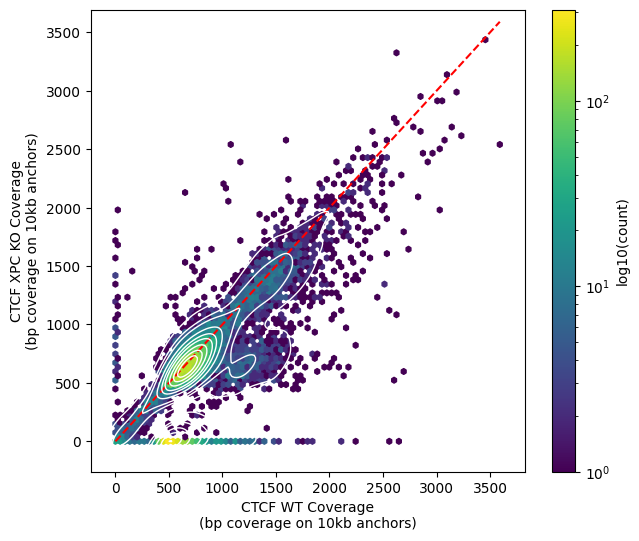

In [13]:
# visualize CTCF coverage in WT vs XPC KO on preserved loop anchors

plt.figure(figsize=(7,6))

# Hexbin
plt.hexbin(
    ctcf_wt_coverage['coverage'],
    ctcf_xpc_ko_coverage['coverage'],
    gridsize=80,
    bins='log',
    cmap='viridis',
)

# Identity line
mx = max(ctcf_wt_coverage['coverage'].max(), ctcf_xpc_ko_coverage['coverage'].max())
plt.plot([0, mx], [0, mx], 'r--', lw=1.5)

# Overlay KDE contours
sns.kdeplot(
    x=ctcf_wt_coverage['coverage'],
    y=ctcf_xpc_ko_coverage['coverage'],
    levels=10,
    color="white",
    linewidths=1,
)

plt.xlabel("CTCF WT Coverage\n(bp coverage on 10kb anchors)")
plt.ylabel("CTCF XPC KO Coverage\n(bp coverage on 10kb anchors)")
plt.colorbar(label="log10(count)")
plt.show()

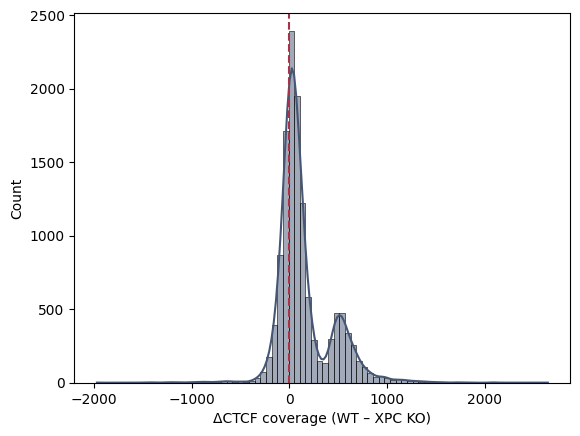

In [41]:
diff = ctcf_wt_coverage['coverage'] - ctcf_xpc_ko_coverage['coverage']

sns.histplot(diff, bins=80, kde=True, color=colors[0])
plt.axvline(0, color=colors[1], linestyle='--')
plt.xlabel("ΔCTCF coverage (WT – XPC KO)")
plt.show()

<Axes: xlabel='coverage', ylabel='Count'>

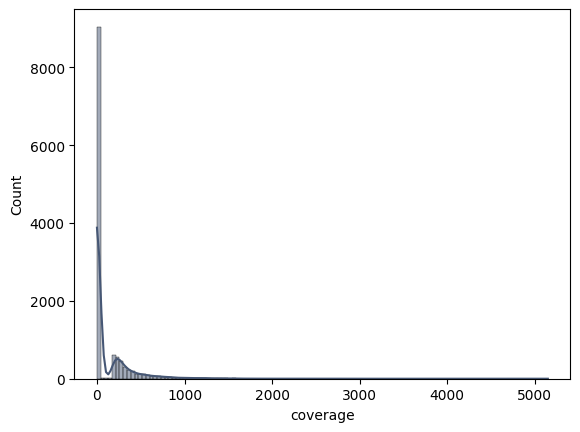

In [42]:
sns.histplot(
    xpc_coverage['coverage'],
    bins=120, kde=True, color=colors[0]
)

In [43]:
# create binary XPC binding column based on coverage (0 = no binding, 1 = binding)

x = xpc_coverage['coverage']

xpc_binary = pd.Series(
    np.where(x == 0, "Zero", "Present"),
    index=x.index,
    name="XPC_binary"
)
ctcf_wt_coverage['xpc_bin'] = xpc_binary
ctcf_xpc_ko_coverage['xpc_bin'] = xpc_binary

In [44]:
# Extract coverage as arrays
wt = ctcf_wt_coverage["coverage"]
ko = ctcf_xpc_ko_coverage["coverage"]

# Boolean mask: keep rows where NOT any zero
mask = ~((wt == 0) | (ko == 0))

# Filter both dfs
ctcf_wt_coverage = ctcf_wt_coverage[mask]
ctcf_xpc_ko_coverage = ctcf_xpc_ko_coverage[mask]

<Figure size 640x480 with 0 Axes>

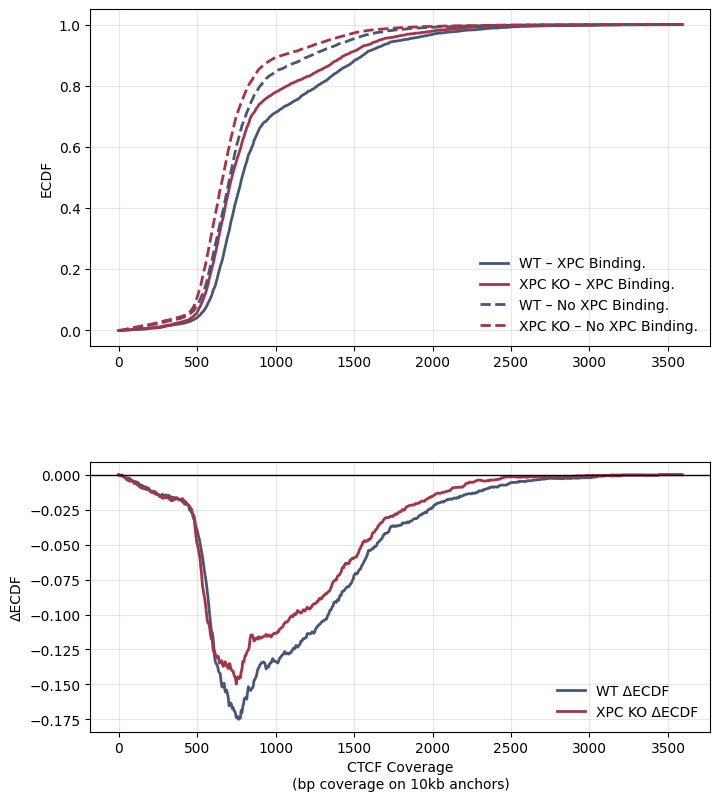

In [45]:
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import mannwhitneyu
import matplotlib.gridspec as gridspec

cov_start = 0

# ------------------------------------------
# Prepare Data
# ------------------------------------------
wt_zero     = ctcf_wt_coverage.loc[xpc_binary == "Zero", "coverage"]
wt_present  = ctcf_wt_coverage.loc[xpc_binary == "Present", "coverage"]
ko_zero     = ctcf_xpc_ko_coverage.loc[xpc_binary == "Zero", "coverage"]
ko_present  = ctcf_xpc_ko_coverage.loc[xpc_binary == "Present", "coverage"]

# ECDF objects
ecdf_wt_zero = ECDF(wt_zero)
ecdf_wt_present = ECDF(wt_present)
ecdf_ko_zero = ECDF(ko_zero)
ecdf_ko_present = ECDF(ko_present)

# x grid
x = np.linspace(cov_start, max(wt_zero.max(), wt_present.max(),
                       ko_zero.max(), ko_present.max()), 700)

# ΔECDF
delta_wt = ecdf_wt_present(x) - ecdf_wt_zero(x)
delta_ko = ecdf_ko_present(x) - ecdf_ko_zero(x)

# ------------------------------------------
# Cliff’s delta
# ------------------------------------------
def cliffs_delta(a, b):
    gt = sum([1 for i in a for j in b if i > j])
    lt = sum([1 for i in a for j in b if i < j])
    n = len(a) * len(b)
    return (gt - lt) / n

cd_wt = cliffs_delta(wt_present, wt_zero)
cd_ko = cliffs_delta(ko_present, ko_zero)

# Mann–Whitney
u_wt, p_wt = mannwhitneyu(wt_zero, wt_present, alternative="two-sided")
u_ko, p_ko = mannwhitneyu(ko_zero, ko_present, alternative="two-sided")

# ------------------------------------------
# Difference Density
# KDE(Present) − KDE(Zero)
# ------------------------------------------
kde_wt_present = sns.kdeplot(wt_present, fill=False).get_lines()[-1].get_data()
plt.clf()
kde_wt_zero = sns.kdeplot(wt_zero, fill=False).get_lines()[-1].get_data()
plt.clf()
kde_ko_present = sns.kdeplot(ko_present, fill=False).get_lines()[-1].get_data()
plt.clf()
kde_ko_zero = sns.kdeplot(ko_zero, fill=False).get_lines()[-1].get_data()
plt.clf()

# Interpolate onto shared grid
xx = np.linspace(cov_start, max(x), 700)
from numpy import interp
wt_kde_diff = interp(xx, kde_wt_present[0], kde_wt_present[1]) - interp(xx, kde_wt_zero[0], kde_wt_zero[1])
ko_kde_diff = interp(xx, kde_ko_present[0], kde_ko_present[1]) - interp(xx, kde_ko_zero[0], kde_ko_zero[1])

# ------------------------------------------
# Plot Setup
# ------------------------------------------
plt.figure(figsize=(8, 18))
gs = gridspec.GridSpec(4, 1, height_ratios=[2.5, 2, 2, 1.2], hspace=0.45)

# ------------------------------------------
# ECDFs
# ------------------------------------------
ax = plt.subplot(gs[0])

ax.plot(x, ecdf_wt_present(x), label="WT – XPC Binding.", lw=2, color=colors[0])
ax.plot(x, ecdf_ko_present(x), label="XPC KO – XPC Binding.", lw=2, color=colors[1])

ax.plot(x, ecdf_wt_zero(x), label="WT – No XPC Binding.", lw=2, ls="--", color=colors[0])
ax.plot(x, ecdf_ko_zero(x), label="XPC KO – No XPC Binding.", lw=2, ls="--", color=colors[1])

ax.set_xlabel("")
ax.set_ylabel("ECDF")
ax.grid(alpha=0.3)
ax.legend(frameon=False)

# ------------------------------------------
# ΔECDF
# ------------------------------------------
ax = plt.subplot(gs[1])

ax.plot(x, delta_wt, label="WT ΔECDF", lw=2, color=colors[0])
ax.plot(x, delta_ko, label="XPC KO ΔECDF", lw=2, color=colors[1])

ax.axhline(0, color="black", lw=1)
ax.set_xlabel("CTCF Coverage\n(bp coverage on 10kb anchors)")
ax.set_ylabel("ΔECDF")
ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.show()

In [46]:
# cliff's delta values
cd_wt, cd_ko

(0.24165813262317953, 0.21003193862822908)

In [47]:
# import CTCF motifs

ctcf_motifs = pd.read_csv('/home/carlos/Clone/ggner-3d/data/CTCF_hg38.bed', sep='\t', header=None) # downloaded with CTCF package from bioconductor
ctcf_motifs.rename(columns={0:'chrom', 1:'start', 2:'end', 3:'motif_id', 4:'strand', 5:'motif_name', 6:'score', 7:'pValue', 8:'qValue', 9:'sequence'}, inplace=True)
ctcf_motifs = ctcf_motifs.loc[ctcf_motifs.pValue <= 1e-5]

In [48]:
# read ctcf and xpc (rpgc) signal in bigwig files with bbi

bigwigs = {
    'wt_ctcf_nouv': [
        '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw',
        '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw'
    ],
    'xpcko_ctcf_nouv': [
        '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP1.mLb.clN.rpgc.bw',
        '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP2.mLb.clN.rpgc.bw'
    ],
    'wt_xpc_nouv': [
        '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw',
        '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw',
        '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw'
    ],
    'wt_atacseq': [
        '/home/carlos/Clone/ctcf_xpc/atac_seq/GSM7089925_ATACseq_WT_noUV_Rep1.bw',
        '/home/carlos/Clone/ctcf_xpc/atac_seq/GSM7089926_ATACseq_WT_noUV_Rep2.bw'
    ]
}

nbins = 1
bigwig_stackups = bbi_stackup_w_replicates(bigwigs, all_anchors, nbins=nbins)

In [49]:
def assign_quartile(signal_value, quartiles):
    if signal_value <= quartiles[0]:
        return 1
    elif signal_value <= quartiles[1]:
        return 2
    elif signal_value <= quartiles[2]:
        return 3
    else:
        return 4

xpc_quartiles = np.percentile(bigwig_stackups['wt_xpc_nouv'], [25, 50, 75])
all_anchors['xpc_q'] = [assign_quartile(val, xpc_quartiles) for val in bigwig_stackups['wt_xpc_nouv']]

In [50]:
all_anchors['ctcf_wt_signal'] = bigwig_stackups['wt_ctcf_nouv']
all_anchors['ctcf_ko_signal'] = bigwig_stackups['xpcko_ctcf_nouv']
all_anchors['delta_ctcf_signal'] = all_anchors['ctcf_wt_signal'] - all_anchors['ctcf_ko_signal']
all_anchors['delta_ctcf_signal_norm'] = (
    all_anchors['delta_ctcf_signal'] - all_anchors['delta_ctcf_signal'].mean()
) / all_anchors['delta_ctcf_signal'].std()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


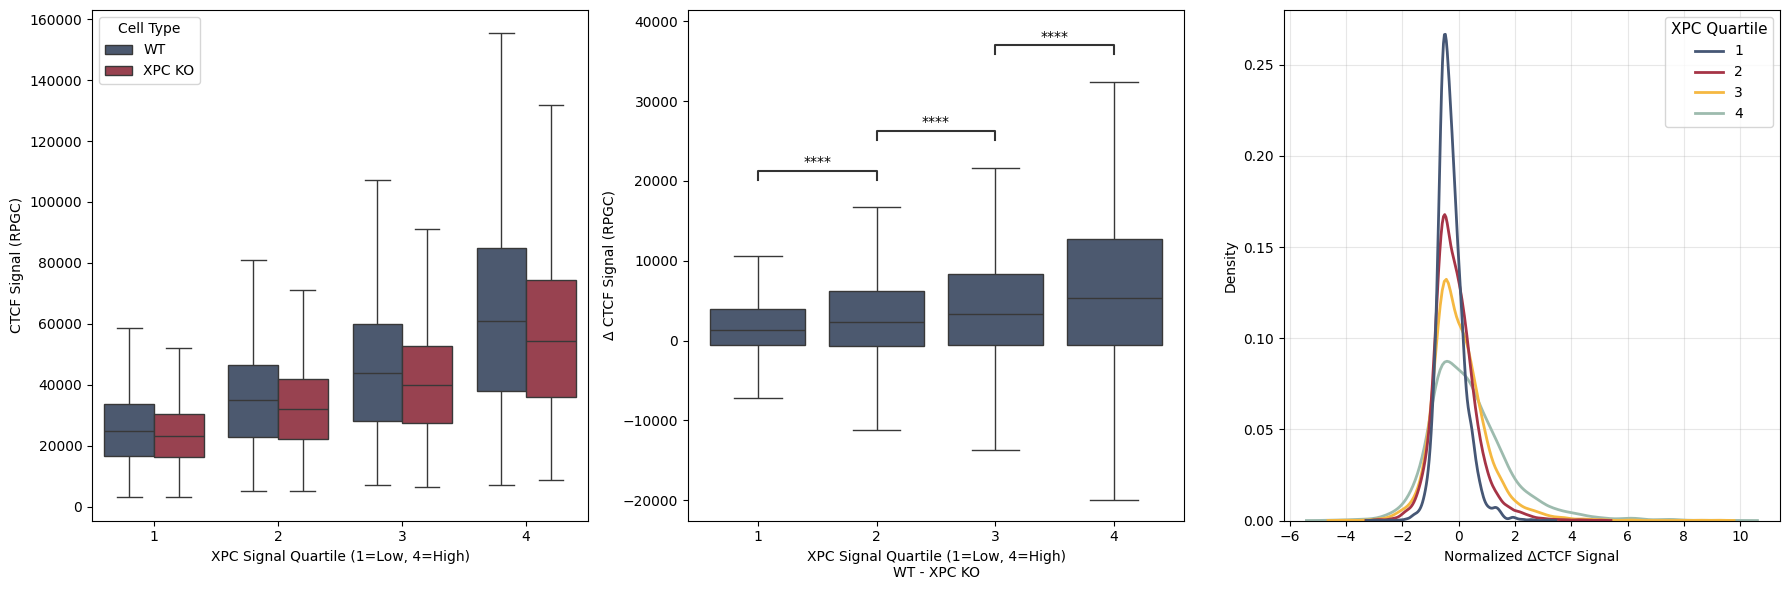

In [51]:
# --- 1. Data Preparation: Melt for Hue ---
# Convert wide format (separate WT/KO columns) into long format for the first plot
plot_data = pd.melt(
    all_anchors, 
    id_vars=['xpc_q'], 
    value_vars=['ctcf_wt_signal', 'ctcf_ko_signal'],
    var_name='Cell Type', 
    value_name='Signal'
)

# Rename for cleaner legend labels
plot_data['Cell Type'] = plot_data['Cell Type'].replace({
    'ctcf_wt_signal': 'WT',
    'ctcf_ko_signal': 'XPC KO'
})

# --- 2. Setup Figure (1 row, 3 columns) ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# -------------------------------------------------------
# Plot 1: Merged WT & KO (axs[0])
# -------------------------------------------------------
sns.boxplot(
    data=plot_data,
    x='xpc_q',
    y='Signal',
    hue='Cell Type',
    ax=axs[0],
    palette=colors[:2],  # Assumes 'colors' list exists; uses first 2
    showfliers=False     # Optional: hides outliers for cleaner view
)
axs[0].set_ylabel('CTCF Signal (RPGC)')
axs[0].legend(title='Cell Type')

# -------------------------------------------------------
# Plot 2: Delta Signal (axs[1])
# -------------------------------------------------------
sns.boxplot(
    data=all_anchors,
    x='xpc_q',
    y='delta_ctcf_signal',
    ax=axs[1],
    color=colors[0],   # Used a neutral color to distinguish from Cell Type
    showfliers=False
)
axs[1].set_ylabel('Δ CTCF Signal (RPGC)')

# -- Annotations for Plot 2 --
pairs = [(1, 2), (2, 3), (3, 4)]
annotator = Annotator(
    axs[1],
    pairs,
    data=all_anchors,
    x="xpc_q",
    y="delta_ctcf_signal"
)
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", verbose=0)
annotator.apply_and_annotate()

# -------------------------------------------------------
# Plot 3: KDE Distribution (axs[2])
# -------------------------------------------------------
sns.kdeplot(
    data=all_anchors,
    x='delta_ctcf_signal_norm',
    hue='xpc_q',
    common_norm=True,
    linewidth=2,
    palette=colors,      # Uses the full palette for quartiles
    ax=axs[2]
)

axs[2].set_xlabel('Normalized ΔCTCF Signal')
axs[2].set_ylabel('Density')
axs[2].grid(alpha=0.3)

# -- Customize Legend for Plot 3 --
# Retrieve the legend created by seaborn on the subplot
leg = axs[2].get_legend()
if leg:
    leg.set_title("XPC Quartile")
    leg.get_title().set_fontsize(11)
    for text in leg.get_texts():
        text.set_fontsize(10)

# --- 3. Final Layout Adjustments ---
axs[0].set_xlabel('XPC Signal Quartile (1=Low, 4=High)')
axs[1].set_xlabel('XPC Signal Quartile (1=Low, 4=High)\nWT - XPC KO')

plt.tight_layout()
plt.show()

In [52]:
clrs_dict = CLR_CONNS(resolution=RESOLUTION, genotype=['WT', 'XPC'], timepoint=['noUV'])
keys = list(clrs_dict.keys())
expected_dfs = {
    keys[0]: get_expected_cis_df(keys[0], resolution_kb=10, label='arm'),
    keys[1]: get_expected_cis_df(keys[1], resolution_kb=10, label='arm')
}

clrs_dict.keys(), expected_dfs.keys()

(dict_keys(['WTnoUV', 'XPCnoUV']), dict_keys(['WTnoUV', 'XPCnoUV']))

In [53]:
all_anchors['xpc_signal'] = bigwig_stackups['wt_xpc_nouv'].reshape(-1).tolist()
all_anchors['atac_signal'] = bigwig_stackups['wt_atacseq'].reshape(-1).tolist()

In [54]:
from ggner_3d.cm import get_eig_data
wt_nouv_compartment_eigvec = get_eig_data('WTnoUV', 100_000)[1]
all_anchors['E1'] = bf.overlap(all_anchors, wt_nouv_compartment_eigvec).dropna()['E1_']

In [55]:
import pandas as pd
import numpy as np

def add_paired_signal_quartiles(
    df: pd.DataFrame, 
    anchors_df: pd.DataFrame, 
    signal_col: str, 
    suffix: str = None
) -> pd.DataFrame:
    """
    Annotates a loop DataFrame with signal values for both anchors, 
    computes the mean signal, and assigns quartiles.

    Parameters:
    -----------
    df : pd.DataFrame
        The DataFrame containing loop coordinates (chrom1, start1, end1, chrom2, etc.).
    anchors_df : pd.DataFrame
        The DataFrame containing anchor signals (chrom, start, end, <signal_col>).
    signal_col : str
        The name of the column in anchors_df containing the signal (e.g., 'xpc_signal').
    suffix : str, optional
        Suffix for the output columns. If None, defaults to signal_col name (e.g., 'xpc_signal_sum').

    Returns:
    --------
    pd.DataFrame
        A new DataFrame with added columns:
        - anchor1_{suffix}
        - anchor2_{suffix}
        - {suffix}_mean
        - {suffix}_q (1-4)
    """
    # 0. Clean Setup
    df_out = df.copy()
    
    # Define output column names
    base_name = suffix if suffix else signal_col
    col_a1 = f'anchor1_{base_name}'
    col_a2 = f'anchor2_{base_name}'
    col_mean = f'{base_name}_mean'
    col_q = f'{base_name}_q'

    # Remove existing columns to ensure a clean re-run
    cols_to_drop = [col_a1, col_a2, col_mean, col_q]
    df_out = df_out.drop(columns=[c for c in cols_to_drop if c in df_out.columns], errors='ignore')

    # 1. Merge for Anchor 1
    # We rename valid anchor cols to avoid collision, then drop the merge keys
    df_out = df_out.merge(
        anchors_df[['chrom', 'start', 'end', signal_col]], 
        left_on=['chrom1', 'start1', 'end1'], 
        right_on=['chrom', 'start', 'end'], 
        how='left'
    ).rename(columns={signal_col: col_a1}).drop(columns=['chrom', 'start', 'end'])

    # 2. Merge for Anchor 2
    df_out = df_out.merge(
        anchors_df[['chrom', 'start', 'end', signal_col]], 
        left_on=['chrom2', 'start2', 'end2'], 
        right_on=['chrom', 'start', 'end'], 
        how='left'
    ).rename(columns={signal_col: col_a2}).drop(columns=['chrom', 'start', 'end'])

    # 3. Calculate Mean Signal
    df_out[col_mean] = df_out[col_a1] + df_out[col_a2]

    # 4. Assign Quartiles
    # pd.qcut is cleaner and faster than manual percentile calculation
    # labels=[1, 2, 3, 4] assigns the quartile number directly
    try:
        df_out[col_q] = pd.qcut(df_out[col_mean], q=4, labels=[1, 2, 3, 4])
    except ValueError:
        # Fallback if too many duplicate values (e.g. lots of zeros) prevent unique bins
        print(f"Warning: Could not determine unique quartiles for {signal_col}. Using rank-based method.")
        df_out[col_q] = pd.qcut(df_out[col_mean].rank(method='first'), q=4, labels=[1, 2, 3, 4])

    return df_out

preserved_df = add_paired_signal_quartiles(
    preserved_df,
    all_anchors,
    signal_col='xpc_signal',
    suffix='xpc_sum'
)

preserved_df = add_paired_signal_quartiles(
    preserved_df,
    all_anchors,
    signal_col='atac_signal',
    suffix='atac_sum'
)

preserved_df = add_paired_signal_quartiles(
    preserved_df,
    all_anchors,
    signal_col='E1',
    suffix='E1_sum'
)

preserved_df = add_paired_signal_quartiles(
    preserved_df,
    all_anchors,
    signal_col='delta_ctcf_signal',
    suffix='delta_ctcf_sum'
)

preserved_df = add_paired_signal_quartiles(
    preserved_df,
    all_anchors,
    signal_col='ctcf_wt_signal',
    suffix='ctcf_wt_sum'
)

preserved_df = add_paired_signal_quartiles(
    preserved_df,
    all_anchors,
    signal_col='ctcf_ko_signal',
    suffix='ctcf_ko_sum'
)

/tmp/ipykernel_909042/251695303.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='XPC quartile')


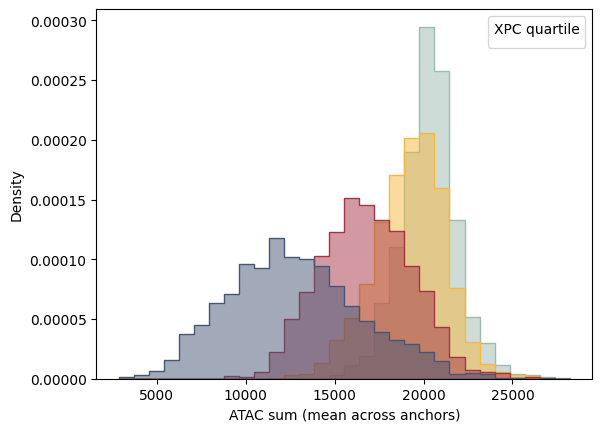

/tmp/ipykernel_909042/251695303.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='XPC quartile')


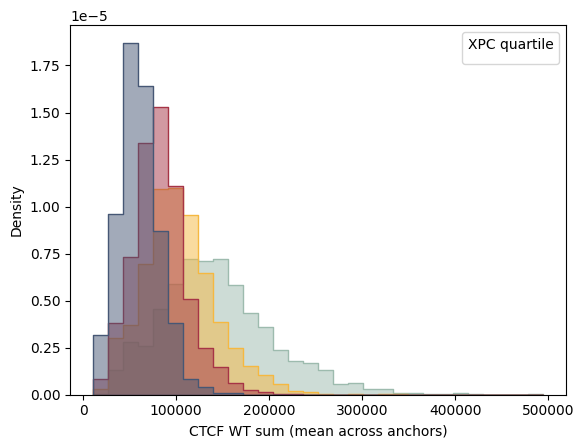

/tmp/ipykernel_909042/251695303.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='XPC quartile')


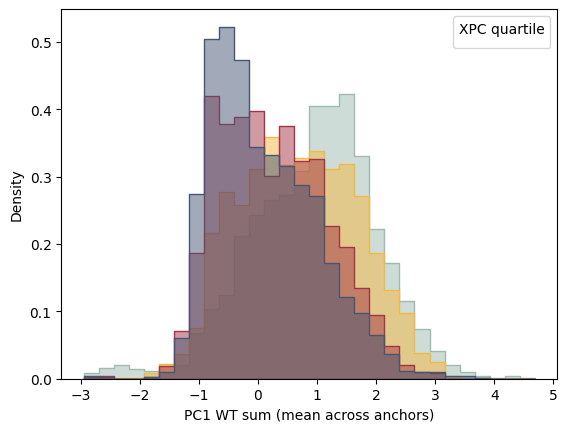

In [56]:
sns.histplot(
    data=preserved_df,
    x='atac_sum_mean',
    hue='xpc_sum_q',
    bins=30,
    alpha=0.5,
    palette=colors,
    element='step',
    stat='density',
    common_norm=False
)
plt.xlabel('ATAC sum (mean across anchors)')
plt.ylabel('Density')
plt.legend(title='XPC quartile')
plt.show()

sns.histplot(
    data=preserved_df,
    x='ctcf_wt_sum_mean',
    hue='xpc_sum_q',
    bins=30,
    alpha=0.5,
    palette=colors,
    element='step',
    stat='density',
    common_norm=False
)
plt.xlabel('CTCF WT sum (mean across anchors)')
plt.ylabel('Density')
plt.legend(title='XPC quartile')
plt.show()


sns.histplot(
    data=preserved_df,
    x='E1_sum_mean',
    hue='xpc_sum_q',
    bins=30,
    alpha=0.5,
    palette=colors,
    element='step',
    stat='density',
    common_norm=False
)
plt.xlabel('PC1 WT sum (mean across anchors)')
plt.ylabel('Density')
plt.legend(title='XPC quartile')
plt.show()

In [57]:
apa_flank = 100_000

suffix = 'xpc_sum'

from ggner_3d.cm import prepare_view_df

view_df = prepare_view_df(arm=True)
pups_ = [
	coolpup.pileup(clr, preserved_df, features_format='bedpe', view_df=view_df, expected_df=expected,
							groupby=[f'{suffix}_q'], flank=apa_flank, nproc=6, local=False)
							for clr, expected in zip(clrs_dict.values(), expected_dfs.values())
]

INFO:coolpuppy:('chr4_p', 'chr4_p'): 132
INFO:coolpuppy:('chr5_p', 'chr5_p'): 168
INFO:coolpuppy:('chr6_p', 'chr6_p'): 275
INFO:coolpuppy:('chr3_p', 'chr3_p'): 285
INFO:coolpuppy:('chr2_p', 'chr2_p'): 418
INFO:coolpuppy:('chr1_p', 'chr1_p'): 460
INFO:coolpuppy:('chr6_q', 'chr6_q'): 387
INFO:coolpuppy:('chr5_q', 'chr5_q'): 515
INFO:coolpuppy:('chr4_q', 'chr4_q'): 487
INFO:coolpuppy:('chr3_q', 'chr3_q'): 422
INFO:coolpuppy:('chr1_q', 'chr1_q'): 448
INFO:coolpuppy:('chr8_p', 'chr8_p'): 189
INFO:coolpuppy:('chr9_p', 'chr9_p'): 126
INFO:coolpuppy:('chr10_p', 'chr10_p'): 166
INFO:coolpuppy:('chr7_p', 'chr7_p'): 317
INFO:coolpuppy:('chr11_p', 'chr11_p'): 221
INFO:coolpuppy:('chr2_q', 'chr2_q'): 602
INFO:coolpuppy:('chr9_q', 'chr9_q'): 229
INFO:coolpuppy:('chr12_p', 'chr12_p'): 155
INFO:coolpuppy:('chr7_q', 'chr7_q'): 283
INFO:coolpuppy:('chr11_q', 'chr11_q'): 313
INFO:coolpuppy:('chr10_q', 'chr10_q'): 417
INFO:coolpuppy:('chr8_q', 'chr8_q'): 521
INFO:coolpuppy:('chr13_q', 'chr13_q'): 236
INFO

In [58]:
corner_size = 6
central_size = 1

from ggner_3d.loop_viz_helpers import get_central_mean, get_corner_ratios, annotate_scores, calculate_symmetric_limits

for pup in pups_:
    pup['central_score'] = pup.apply(
                    lambda x: get_central_mean(x['data'], central_size), axis=1
                )

for pup in pups_:
    pup['corner_scores'] = pup.apply(
                    lambda x: get_corner_ratios(x['data'], corner_size), axis=1
                )

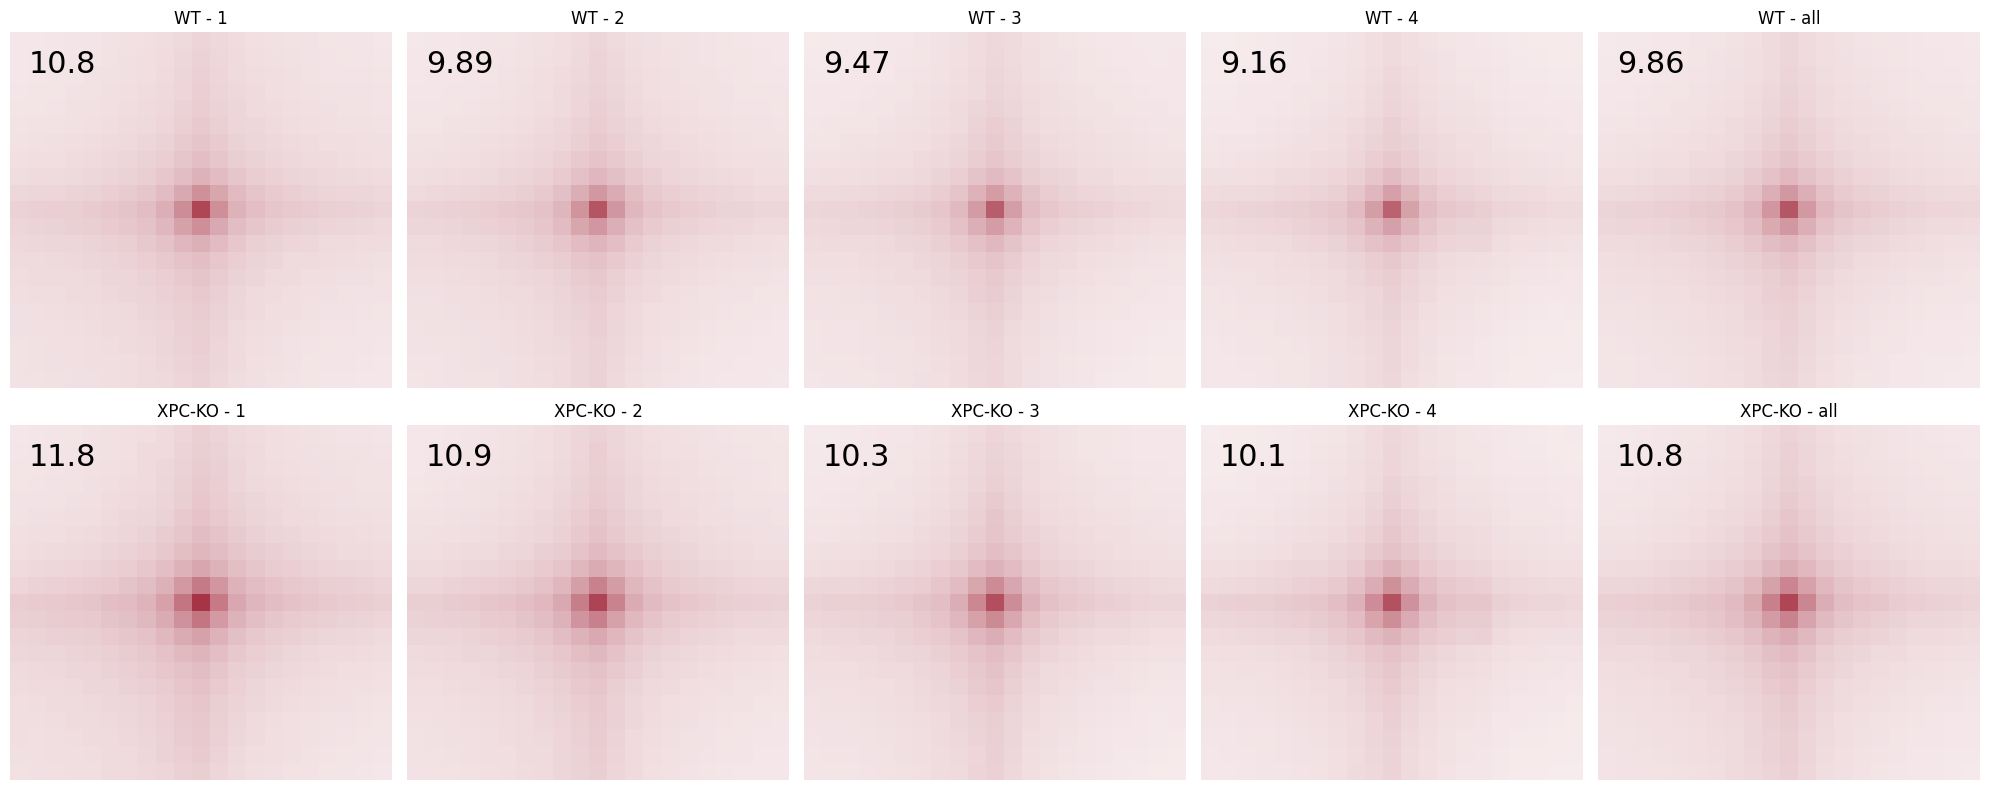

In [59]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
vmin, vmax = calculate_symmetric_limits(pups_)

from matplotlib.colors import LinearSegmentedColormap
cmp = LinearSegmentedColormap.from_list("custom_cmp", ["white", colors[1]], N=256)

for i, pup in enumerate(pups_):
    for j, (name, group) in enumerate(pup.groupby(f'{suffix}_q')):
        ax = axs[i, j]
        # drop 1st dim (1,21,21)
        mtx = np.stack(group['data'].values).mean(axis=0)
        s = sns.heatmap(
            mtx,
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            cmap=cmp,
            cbar=False,
            xticklabels=False,
            yticklabels=False
        )
        ax.set_title(f"{'WT' if i == 0 else 'XPC-KO'} - {name}")
        annotate_scores('central_score', np.nanmean(group['central_score']), ax, mtx.shape[0], corner_size)
        # annotate_scores('corner_scores', np.nanmean(np.stack(group['corner_scores'].values), axis=0), ax, mtx.shape[0], corner_size)
plt.tight_layout()
plt.show()

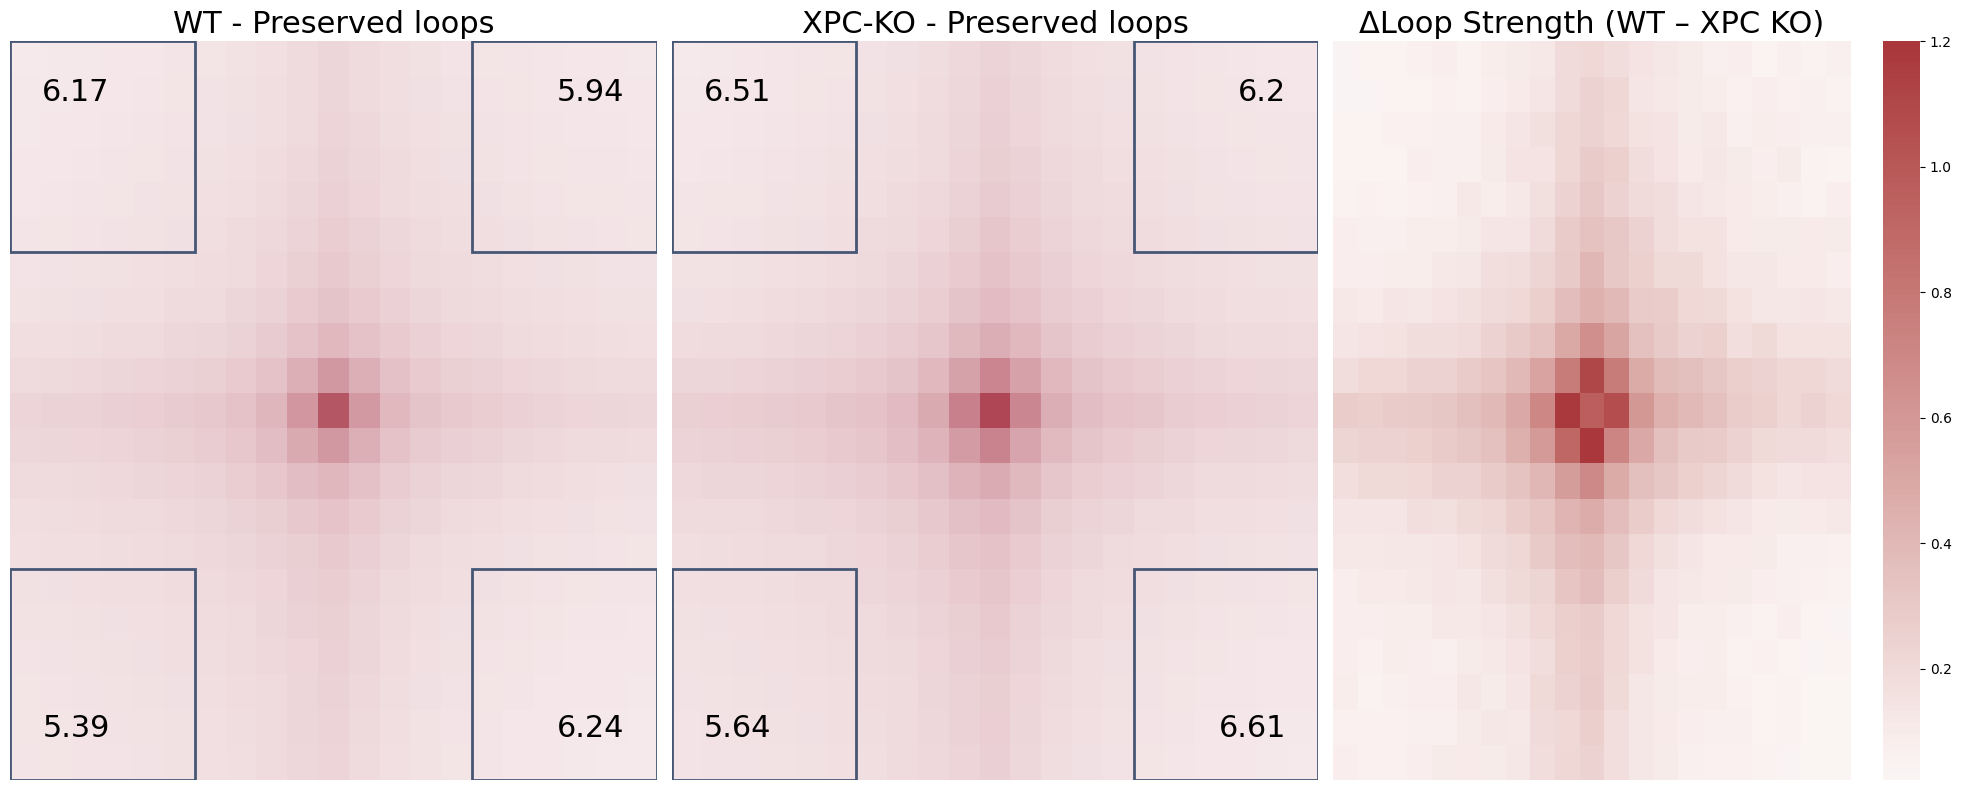

In [ ]:
wt_all_mtx = pups_[0].loc[pups_[0].xpc_sum_q == 'all']['data'].reset_index(drop=True)[0]
wt_all_central_score = pups_[0].loc[pups_[0].xpc_sum_q == 'all'].central_score.values[0]
wt_all_corner_scores = pups_[0].loc[pups_[0].xpc_sum_q == 'all'].corner_scores.values[0]
ko_all_mtx = pups_[1].loc[pups_[1].xpc_sum_q == 'all']['data'].reset_index(drop=True)[0]
ko_all_central_score = pups_[1].loc[pups_[1].xpc_sum_q == 'all'].central_score.values[0]
ko_all_corner_scores = pups_[1].loc[pups_[1].xpc_sum_q == 'all'].corner_scores.values[0]

diff_mtx = ko_all_mtx - wt_all_mtx
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
sns.heatmap(
    wt_all_mtx,
    ax=ax[0],
    vmin=vmin,
    vmax=vmax,
    cmap=cmp,
    cbar=False,
    xticklabels=False,
    yticklabels=False,
)
annotate_scores('corner_scores', wt_all_corner_scores, ax[0], wt_all_mtx.shape[0], corner_size)
ax[0].set_title("WT - Preserved loops", fontsize=22)

sns.heatmap(
    ko_all_mtx,
    ax=ax[1],
    vmin=vmin,
    vmax=vmax,
    cmap=cmp,
    cbar=False,
    xticklabels=False,
    yticklabels=False,
)
ax[1].set_title("XPC-KO - Preserved loops", fontsize=22)
annotate_scores('corner_scores', ko_all_corner_scores, ax[1], ko_all_mtx.shape[0], corner_size)
sns.heatmap(
    diff_mtx,
    ax=ax[2],
    center=0,
    cmap='vlag',
    cbar=True,
    xticklabels=False,
    yticklabels=False,
)
ax[2].set_title("ΔLoop Strength (XPC KO – WT)", fontsize=22)
plt.tight_layout()
plt.show()